Optimization (Base Case) + Calibration (Policy)

In [13]:
pip install pysd scipy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [14]:
# Policy Model Calibration and Optimization
# This notebook calibrates the policy model (with interventions) to real-world data

import numpy as np
import pandas as pd
from scipy.integrate import odeint
from scipy.optimize import minimize, differential_evolution
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [15]:
# ==========================================
# LOAD REAL-WORLD DATA
# ==========================================
# Load and prepare malaria incidence data from CSV
malaria_data = pd.read_csv('incidence-of-malaria.csv')
malaria_data['Year'] = malaria_data['Year']

# Convert from "per 1,000 population" to percentage (0-100 scale)
# Example: 394.98 per 1,000 = 39.498% of population
incidence_per_1000 = malaria_data['Incidence of malaria (per 1,000 population at risk)']
malaria_data['Incidence_percentage'] = incidence_per_1000 / 10  # Convert to percentage

# Filter to years 2000-2023
malaria_calibration = malaria_data[malaria_data['Year'] >= 2000].copy()

print(f"Loaded {len(malaria_calibration)} data points from CSV (years 2000-2023)")
print(f"Data converted to percentage format (0-100 scale)")
print(f"\nSample data:")
print(malaria_calibration[['Year', 'Incidence_percentage']].head())

# ==========================================
# POLICY MODEL SIMULATION ENGINE
# Based on balariainbali-Policies.mdl
# ==========================================
def run_policy_model(policy_params, time_points, calibrated_base_params=None):
    # Unpack Decision Variables
    frac_gdp = policy_params['Fraction_GDP_Prevention']
    net_share = policy_params['Net_Allocation_Share']

    # Use calibrated base case parameters if provided, otherwise use defaults
    if calibrated_base_params is None:
        # Default parameters (from BaseCaseSFD.mdl)
        biting_rate = 15.0
        trans_prob_h_to_m = 0.3
        trans_prob_m_to_h = 0.3
        mosquito_repro_rate = 1.5
        cost_per_case = 100.0
    else:
        # Use calibrated parameters from base case calibration
        biting_rate = calibrated_base_params.get('Biting_rate', 15.0)
        trans_prob_m_to_h = calibrated_base_params.get('Transmission_Probability', 0.3)
        trans_prob_h_to_m = 0.3  # Fixed parameter
        mosquito_repro_rate = calibrated_base_params.get('Mosquito_Reproduction_Rate', 1.5)
        cost_per_case = calibrated_base_params.get('Cost_per_case', 100.0)

    # --- Common Efficiencies & Costs ---
    eff_nets = 0.7   # 70% efficacy for nets
    eff_vax = 0.8    # 80% efficacy for vaccines
    # Cost to cover 1 person fully (Assumption: Nets $2.50 + Vax $7.50 = ~$10)
    cost_full_coverage = 10.0

    # --- Core Constant Parameters ---
    params = {
        'human_carrying_capacity': 2e7,
        'birth_rate_human': 0.005,
        'natural_mortality_human': 0.00069,
        'base_duration_infection': 0.5,
        'base_malaria_mortality': 0.05,
        'duration_immunity': 6.0,

        'mosquito_carrying_capacity': 1e10,
        'mosquito_life_expectancy': 1.5,
        'mosquito_incubation_period': 0.4,

        'gdp_max': 4500.0,
        'cost_per_case': cost_per_case,  # Use calibrated cost if provided
        'drag_time_constant': 164.0,
        'gdp_scale': 1.0
    }

    # Initial State [HS, HI, HR, MS, ME, MI, GDP]
    y0 = [1.8e7, 2.5e6, 0.0, 3e7, 1e5, 8e6, 800.0]

    def derivs(y, t):
        HS, HI, HR, MS, ME, MI, GDP = y

        # Guard against negative values
        HS, HI, HR = max(0, HS), max(0, HI), max(0, HR)
        MS, ME, MI = max(0, MS), max(0, ME), max(0, MI)
        GDP = max(0, GDP)

        # 1. Calculate Dynamic Funding & Coverage
        # Note: Funding depends on GDP state
        prevention_funding = GDP * frac_gdp

        # Calculate dynamic coverage (Capped at 1.0 or 100%)
        # Logic: If you have $30 and cost is $10, you cover 3 people.
        # But we are dealing with fractions of population, so we divide by Cost per Person.
        cov_nets = min(1.0, (prevention_funding * net_share) / cost_full_coverage)
        cov_vax = min(1.0, (prevention_funding * (1 - net_share)) / cost_full_coverage)

        # 2. Apply Interventions to Biological Rates
        # Mechanism: Nets reduce Biting Rate
        b_curr = biting_rate * (1 - (cov_nets * eff_nets))

        # Mechanism: Vaccines reduce Transmission Probability (M to H)
        beta_curr = trans_prob_m_to_h * (1 - (cov_vax * eff_vax))

        # 3. Flows
        total_pop_h = max(1.0, HS + HI + HR)
        total_pop_m = max(1.0, MS + ME + MI)

        # Auxiliaries
        gdp_ref = GDP / params['gdp_scale']
        hq_index = 0.05 + 0.75 / (1 + np.exp(-0.00375 * (gdp_ref - 1440)))

        # Infection Rates
        inf_rate_human = (beta_curr * b_curr * (MI / total_pop_m) * HS)
        inf_rate_mosq = (trans_prob_h_to_m * b_curr * (HI / total_pop_h) * MS)

        # Human Derivatives
        births = total_pop_h * params['birth_rate_human'] * (1 - (total_pop_h / params['human_carrying_capacity']))
        recovery = HI * (1 + hq_index) / params['base_duration_infection']
        waning = HR / params['duration_immunity']
        deaths_malaria = HI * params['base_malaria_mortality'] * (1 - hq_index)

        dHS = births + waning - inf_rate_human - (HS * params['natural_mortality_human'])
        dHI = inf_rate_human - deaths_malaria - recovery - (HI * params['natural_mortality_human'])
        dHR = recovery - waning - (HR * params['natural_mortality_human'])

        # Mosquito Derivatives
        m_births = total_pop_m * mosquito_repro_rate * (1 - (total_pop_m / params['mosquito_carrying_capacity']))
        latent = ME / params['mosquito_incubation_period']

        dMS = m_births - (MS / params['mosquito_life_expectancy']) - inf_rate_mosq
        dME = inf_rate_mosq - latent - (ME / params['mosquito_life_expectancy'])
        dMI = latent - (MI / params['mosquito_life_expectancy'])

        # Economic Derivatives
        growth = 0.015 * np.exp(-gdp_ref / 5000) * GDP
        loss_malaria = (HI * params['cost_per_case']) / total_pop_h
        loss_non_malaria = (GDP / params['drag_time_constant']) * (GDP / params['gdp_max'])**4
        dGDP = growth - (loss_malaria + loss_non_malaria)

        return [dHS, dHI, dHR, dMS, dME, dMI, dGDP]

    res = odeint(derivs, y0, time_points)

    # Convert result to DataFrame
    df = pd.DataFrame(res, columns=['HS','HI','HR','MS','ME','MI','GDP'])
    df['Time'] = time_points
    df['Total_Human_Pop'] = df['HS'] + df['HI'] + df['HR']
    
    # Calculate incidence as percentage (0-100 scale) to match real data format
    df['Incidence_percentage'] = (df['HI'] / df['Total_Human_Pop']) * 100

    # Calculate realized coverages (for reporting)
    df['Funding'] = df['GDP'] * frac_gdp
    df['Cov_Nets'] = np.minimum(1.0, (df['Funding'] * net_share) / cost_full_coverage)
    df['Cov_Vax'] = np.minimum(1.0, (df['Funding'] * (1 - net_share)) / cost_full_coverage)

    return df

print("Policy model simulation engine defined!")

# ==========================================
# POLICY MODEL CALIBRATION
# Calibrate policy parameters to match real-world data
# ==========================================
def calibrate_policy_model(malaria_data, calibrated_base_params=None, start_year=2000):
    """
    Calibrate policy model parameters to match real-world data
    
    Uses scipy.optimize.minimize to find policy parameters (Fraction_GDP_Prevention
    and Net_Allocation_Share) that minimize error between model output and real data.
    
    Parameters:
    -----------
    malaria_data : DataFrame
        Real-world malaria incidence data (with Incidence_percentage column)
    calibrated_base_params : dict, optional
        Calibrated base case parameters. If None, uses default values.
    start_year : int
        Starting year for calibration (default: 2000)
    """
    print(f"\n{'='*60}")
    print("STARTING POLICY MODEL CALIBRATION")
    print(f"{'='*60}")
    print(f"Calibration period: {start_year}-{malaria_data['Year'].max()}")
    print(f"Data points: {len(malaria_data)} years")
    
    if calibrated_base_params:
        print(f"\nUsing calibrated base case parameters:")
        for key, val in calibrated_base_params.items():
            print(f"  - {key}: {val}")
    else:
        print("\nUsing default base case parameters")
    
    # Prepare time vector (in months, starting from start_year)
    years = malaria_data['Year'].values
    months = (years - start_year) * 12
    
    # Get real data values (in percentage format)
    real_incidence = malaria_data['Incidence_percentage'].values
    
    # Policy parameters to calibrate
    bounds = [
        (0.001, 0.05),  # Fraction_GDP_Prevention (0.1% to 5%)
        (0.0, 1.0)      # Net_Allocation_Share (0% to 100% to nets)
    ]
    
    initial_guess = [0.005, 0.5]  # 0.5% GDP, 50% to nets
    
    def objective_function(x):
        """Minimize error between policy model and real data"""
        policy_params = {
            'Fraction_GDP_Prevention': x[0],
            'Net_Allocation_Share': x[1]
        }
        
        try:
            # Run policy model with calibrated base parameters
            model_output = run_policy_model(policy_params, months, calibrated_base_params)
            
            # Extract model incidence (in percentage format)
            model_incidence = model_output['Incidence_percentage'].values
            
            # Use normalized SSE (normalize by mean of real data)
            mean_real = np.mean(real_incidence)
            normalized_sse = np.sum(((model_incidence - real_incidence) / mean_real)**2)
            
            # Penalize if model goes to unrealistic values
            if np.any(model_incidence < 0) or np.any(model_incidence > 100):
                return 1e9
            
            return normalized_sse
            
        except Exception as e:
            return 1e9
    
    # Run optimization
    print("\nRunning policy model calibration (this may take several minutes)...")
    result = minimize(
        objective_function,
        initial_guess,
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 100, 'disp': True}
    )
    
    # Extract calibrated policy parameters
    calibrated_policy_params = {
        'Fraction_GDP_Prevention': result.x[0],
        'Net_Allocation_Share': result.x[1]
    }
    
    # Calculate final fit metrics
    final_output = run_policy_model(calibrated_policy_params, months, calibrated_base_params)
    final_incidence = final_output['Incidence_percentage'].values
    
    final_sse = np.sum((final_incidence - real_incidence)**2)
    final_rmse = np.sqrt(np.mean((final_incidence - real_incidence)**2))
    final_mape = np.mean(np.abs((final_incidence - real_incidence) / real_incidence)) * 100
    final_r2 = 1 - (np.sum((final_incidence - real_incidence)**2) / 
                    np.sum((real_incidence - np.mean(real_incidence))**2))
    
    # Print results
    print(f"\n{'='*60}")
    print("POLICY MODEL CALIBRATION RESULTS")
    print(f"{'='*60}")
    print(f"Optimization Status: {result.message}")
    print(f"Final SSE: {final_sse:.2f}")
    print(f"Final RMSE: {final_rmse:.2f} (incidence percentage)")
    print(f"Final MAPE: {final_mape:.2f}%")
    print(f"R-squared: {final_r2:.4f}")
    
    # Quality assessment
    if final_mape < 20:
        quality = "EXCELLENT"
    elif final_mape < 40:
        quality = "GOOD"
    elif final_mape < 60:
        quality = "FAIR"
    else:
        quality = "POOR - Model may need structural changes"
    print(f"Fit Quality: {quality}")
    
    print(f"\nCalibrated Policy Parameters:")
    print(f"  - Fraction GDP for Prevention: {calibrated_policy_params['Fraction_GDP_Prevention']*100:.3f}%")
    print(f"  - Net Allocation Share:       {calibrated_policy_params['Net_Allocation_Share']*100:.1f}%")
    print(f"  - Vaccine Allocation Share:   {(1-calibrated_policy_params['Net_Allocation_Share'])*100:.1f}%")
    
    # Calculate average coverage
    avg_nets = final_output['Cov_Nets'].mean() * 100
    avg_vax = final_output['Cov_Vax'].mean() * 100
    print(f"\nResulting Average Coverage:")
    print(f"  - Average Bed Net Coverage:    {avg_nets:.1f}%")
    print(f"  - Average Vaccine Coverage:    {avg_vax:.1f}%")
    
    return calibrated_policy_params, final_output, result

# ==========================================
# POLICY OPTIMIZATION (Minimize Disease Burden)
# ==========================================
def optimize_policy_strategy(calibrated_base_params=None):
    """
    Optimize policy parameters to minimize disease burden
    Finds optimal GDP allocation and net/vaccine split
    """
    print("\n" + "="*60)
    print("OPTIMIZING POLICY STRATEGY")
    print("="*60)
    print("Finding optimal intervention allocation to minimize total infections...")
    
    # Bounds
    bounds = [(0.005, 0.05), (0.0, 1.0)]  # GDP fraction, Net allocation share
    
    def objective(x):
        policy_params = {
            'Fraction_GDP_Prevention': x[0],
            'Net_Allocation_Share': x[1]
        }
        
        # Run policy model
        df = run_policy_model(policy_params, np.linspace(0, 120, 120), calibrated_base_params)
        
        # Objective: Minimize Cumulative Infections
        return df['HI'].sum()
    
    # Global Optimization
    print("Running optimization (this may take a few minutes)...")
    result = differential_evolution(objective, bounds, seed=42, strategy='best1bin', maxiter=100)
    
    opt_frac_gdp = result.x[0]
    opt_share = result.x[1]
    
    # Rerun best case to get details
    best_p = {'Fraction_GDP_Prevention': opt_frac_gdp, 'Net_Allocation_Share': opt_share}
    final_df = run_policy_model(best_p, np.linspace(0, 120, 120), calibrated_base_params)
    
    avg_nets = final_df['Cov_Nets'].mean() * 100
    avg_vax = final_df['Cov_Vax'].mean() * 100
    
    print(f"\nOptimization Successful!")
    print(f"-"*30)
    print(f"Optimal GDP Spend:      {opt_frac_gdp*100:.2f}% (Bound: 0.5% - 5%)")
    print(f"Optimal Allocation:     {opt_share*100:.1f}% to Nets / {(1-opt_share)*100:.1f}% to Vaccines")
    print(f"-"*30)
    print(f"Resulting Average Coverage:")
    print(f"  - Avg Bed Net Cov:    {avg_nets:.1f}%")
    print(f"  - Avg Vaccine Cov:    {avg_vax:.1f}%")
    print(f"-"*30)
    
    return result

# ==========================================
# RUN CALIBRATION
# ==========================================
# Note: You can load calibrated base case parameters from ModelCalibration_BaseCase.ipynb
# For now, we'll use None to use default parameters, or you can manually set them:
calibrated_base_params = {
     'Biting_rate': 47.43,
     'Transmission_Probability': 0.755,
     'Duration_of_Immunity': 3.0,
     'Mosquito_Reproduction_Rate': 3.38,
     'Cost_per_case': 310.64
 }

print("\n" + "="*60)
print("CALIBRATING POLICY MODEL WITH REAL-WORLD DATA")
print("="*60)
print("Note: Using default base case parameters.")
print("To use calibrated base case parameters, load them from ModelCalibration_BaseCase.ipynb")
print("and pass them as 'calibrated_base_params' argument.\n")

# Run policy model calibration
calibrated_policy_params, policy_model_results, policy_opt_result = calibrate_policy_model(
    malaria_calibration,
    calibrated_base_params=calibrated_base_params  # Set to calibrated params from base case if available
)

Loaded 24 data points from CSV (years 2000-2023)
Data converted to percentage format (0-100 scale)

Sample data:
   Year  Incidence_percentage
0  2000                39.498
1  2001                39.622
2  2002                40.509
3  2003                41.236
4  2004                41.789
Policy model simulation engine defined!

CALIBRATING POLICY MODEL WITH REAL-WORLD DATA
Note: Using default base case parameters.
To use calibrated base case parameters, load them from ModelCalibration_BaseCase.ipynb
and pass them as 'calibrated_base_params' argument.


STARTING POLICY MODEL CALIBRATION
Calibration period: 2000-2023
Data points: 24 years

Using calibrated base case parameters:
  - Biting_rate: 47.43
  - Transmission_Probability: 0.755
  - Duration_of_Immunity: 3.0
  - Mosquito_Reproduction_Rate: 3.38
  - Cost_per_case: 310.64

Running policy model calibration (this may take several minutes)...

POLICY MODEL CALIBRATION RESULTS
Optimization Status: CONVERGENCE: RELATIVE REDUCTION OF 

In [19]:
# ==========================================
# MODEL FIT QUALITY SUMMARY
# ==========================================
print("\n" + "="*70)
print("POLICY MODEL FIT QUALITY ASSESSMENT")
print("="*70)

# Calculate all fit metrics
years = malaria_calibration['Year'].values
real_incidence = malaria_calibration['Incidence_percentage'].values
policy_years = policy_model_results['Time'] / 12 + 2000
policy_incidence = policy_model_results['Incidence_percentage'].values

# Ensure same length (interpolate if needed)
if len(policy_incidence) != len(real_incidence):
    from scipy.interpolate import interp1d
    interp_func = interp1d(policy_years, policy_incidence, kind='linear', 
                           fill_value='extrapolate', bounds_error=False)
    policy_incidence = interp_func(years)

# Calculate metrics
sse = np.sum((policy_incidence - real_incidence)**2)
mse = np.mean((policy_incidence - real_incidence)**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(policy_incidence - real_incidence))
mape = np.mean(np.abs((policy_incidence - real_incidence) / real_incidence)) * 100
r2 = 1 - (np.sum((policy_incidence - real_incidence)**2) / 
          np.sum((real_incidence - np.mean(real_incidence))**2))

# Determine fit quality
if mape < 10:
    quality = "EXCELLENT"
    quality_color = "🟢"
elif mape < 20:
    quality = "VERY GOOD"
    quality_color = "🟢"
elif mape < 40:
    quality = "GOOD"
    quality_color = "🟡"
elif mape < 60:
    quality = "FAIR"
    quality_color = "🟠"
else:
    quality = "POOR"
    quality_color = "🔴"

# Print formatted summary
print(f"\n{quality_color} OVERALL FIT QUALITY: {quality}")
print(f"\n{'Metric':<30} {'Value':<20} {'Interpretation':<30}")
print("-" * 80)

# RMSE
if rmse < 5:
    rmse_interp = "Excellent (very low error)"
elif rmse < 10:
    rmse_interp = "Good (low error)"
elif rmse < 20:
    rmse_interp = "Fair (moderate error)"
else:
    rmse_interp = "Poor (high error)"
print(f"{'RMSE':<30} {rmse:.2f}%{'':<15} {rmse_interp}")

# MAE
if mae < 5:
    mae_interp = "Excellent (very low error)"
elif mae < 10:
    mae_interp = "Good (low error)"
elif mae < 20:
    mae_interp = "Fair (moderate error)"
else:
    mae_interp = "Poor (high error)"
print(f"{'MAE (Mean Absolute Error)':<30} {mae:.2f}%{'':<15} {mae_interp}")

# MAPE
if mape < 10:
    mape_interp = "Excellent (<10% error)"
elif mape < 20:
    mape_interp = "Very Good (10-20% error)"
elif mape < 40:
    mape_interp = "Good (20-40% error)"
elif mape < 60:
    mape_interp = "Fair (40-60% error)"
else:
    mape_interp = "Poor (>60% error)"
print(f"{'MAPE (Mean Abs % Error)':<30} {mape:.2f}%{'':<15} {mape_interp}")

# R-squared
if r2 > 0.9:
    r2_interp = "Excellent (explains >90% variance)"
elif r2 > 0.7:
    r2_interp = "Good (explains 70-90% variance)"
elif r2 > 0.5:
    r2_interp = "Fair (explains 50-70% variance)"
elif r2 > 0:
    r2_interp = "Poor (explains <50% variance)"
else:
    r2_interp = "Very Poor (negative R², worse than mean)"
print(f"{'R-squared':<30} {r2:.4f}{'':<15} {r2_interp}")

# SSE
print(f"{'SSE (Sum Squared Errors)':<30} {sse:.2f}{'':<15} Lower is better")

print("\n" + "-" * 80)

# Store metrics in a dictionary for easy access
fit_metrics = {
    'RMSE': rmse,
    'MAE': mae,
    'MAPE': mape,
    'R_squared': r2,
    'SSE': sse,
    'Quality': quality
}



POLICY MODEL FIT QUALITY ASSESSMENT

🔴 OVERALL FIT QUALITY: POOR

Metric                         Value                Interpretation                
--------------------------------------------------------------------------------
RMSE                           31.26%                Poor (high error)
MAE (Mean Absolute Error)      31.11%                Poor (high error)
MAPE (Mean Abs % Error)        80.70%                Poor (>60% error)
R-squared                      -111.1452                Very Poor (negative R², worse than mean)
SSE (Sum Squared Errors)       23452.35                Lower is better

--------------------------------------------------------------------------------


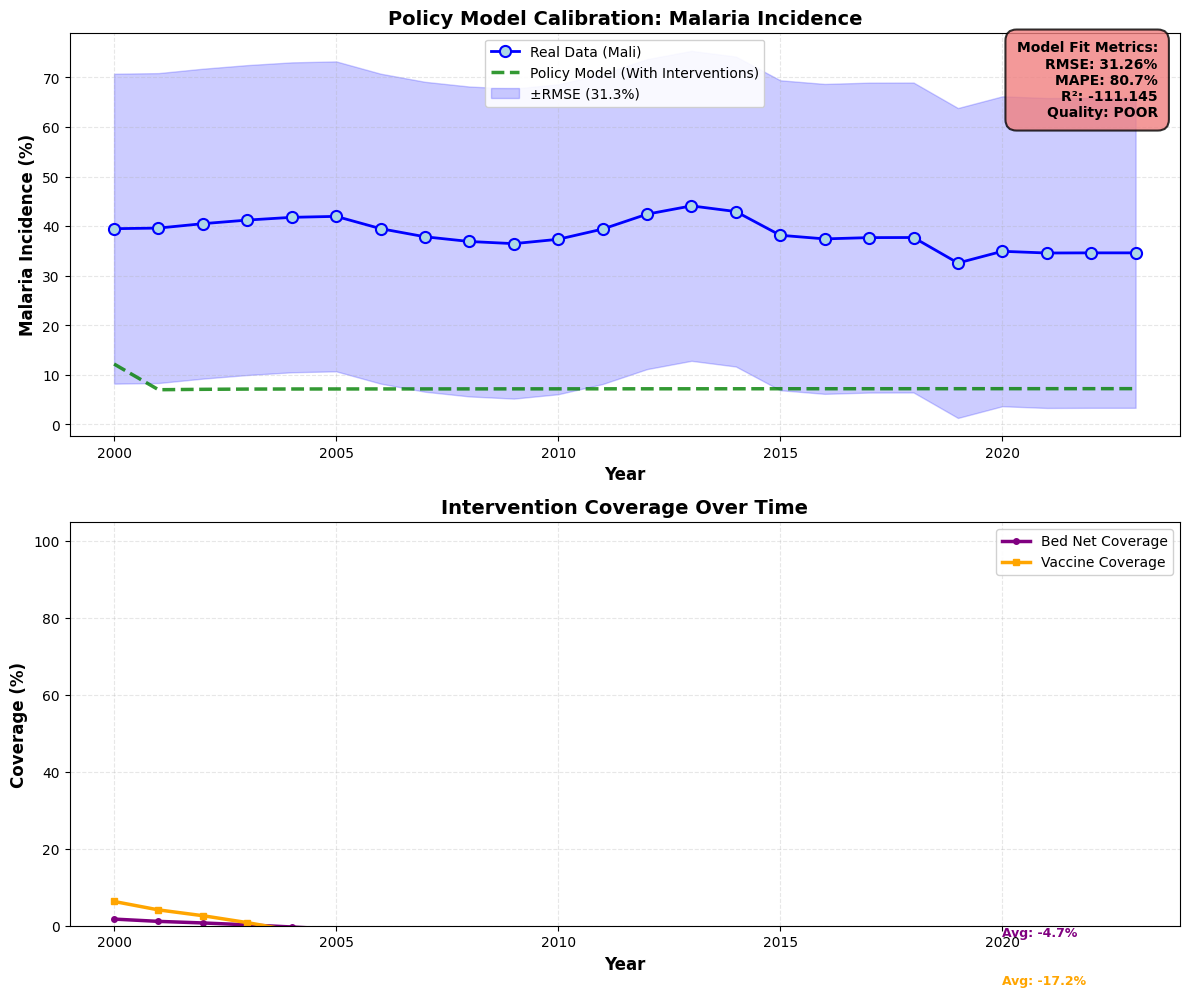


✓ Policy model calibration visualization complete!
  Model fit quality: POOR (MAPE: 80.70%, R²: -111.145)


In [17]:
# ==========================================
# VISUALIZE POLICY MODEL CALIBRATION
# ==========================================
import matplotlib.pyplot as plt

# Create comparison plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Policy Model vs Real Data
ax1 = axes[0]
years = malaria_calibration['Year'].values
real_incidence = malaria_calibration['Incidence_percentage'].values

# Get policy model output
policy_years = policy_model_results['Time'] / 12 + 2000
policy_incidence_full = policy_model_results['Incidence_percentage'].values

# Interpolate to match data years if needed
if len(policy_incidence_full) != len(real_incidence):
    from scipy.interpolate import interp1d
    interp_func = interp1d(policy_years, policy_incidence_full, kind='linear', 
                           fill_value='extrapolate', bounds_error=False)
    policy_incidence = interp_func(years)
else:
    policy_incidence = policy_incidence_full

ax1.plot(years, real_incidence, 'o-', label='Real Data (Mali)', linewidth=2, 
         markersize=8, color='blue', markerfacecolor='lightblue', markeredgewidth=1.5)
ax1.plot(years, policy_incidence, '-', label='Policy Model (With Interventions)', 
         linewidth=2.5, color='green', alpha=0.8, linestyle='--')

# Add error bars or shaded region to show uncertainty
ax1.fill_between(years, real_incidence - rmse, real_incidence + rmse, 
                 alpha=0.2, color='blue', label=f'±RMSE ({rmse:.1f}%)')

ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('Malaria Incidence (%)', fontsize=12, fontweight='bold')
ax1.set_title('Policy Model Calibration: Malaria Incidence', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='best', framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(1999, 2024)

# Add text box with fit metrics (more prominent)
textstr = f'Model Fit Metrics:\n'
textstr += f'RMSE: {rmse:.2f}%\n'
textstr += f'MAPE: {mape:.1f}%\n'
textstr += f'R²: {r2:.3f}\n'
textstr += f'Quality: {quality}'

# Color code the box based on quality
if quality in ["EXCELLENT", "VERY GOOD"]:
    box_color = 'lightgreen'
elif quality == "GOOD":
    box_color = 'lightyellow'
elif quality == "FAIR":
    box_color = 'wheat'
else:
    box_color = 'lightcoral'

props = dict(boxstyle='round,pad=0.8', facecolor=box_color, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.text(0.98, 0.98, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', horizontalalignment='right', bbox=props, fontweight='bold')

# Plot 2: Coverage Over Time
ax2 = axes[1]
ax2.plot(policy_years, policy_model_results['Cov_Nets']*100, '-', 
         label='Bed Net Coverage', linewidth=2.5, color='purple', marker='o', markersize=4)
ax2.plot(policy_years, policy_model_results['Cov_Vax']*100, '-', 
         label='Vaccine Coverage', linewidth=2.5, color='orange', marker='s', markersize=4)
ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Coverage (%)', fontsize=12, fontweight='bold')
ax2.set_title('Intervention Coverage Over Time', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='best', framealpha=0.9)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(1999, 2024)
ax2.set_ylim(0, 105)

# Add average coverage annotation
avg_nets = policy_model_results['Cov_Nets'].mean() * 100
avg_vax = policy_model_results['Cov_Vax'].mean() * 100
ax2.axhline(y=avg_nets, color='purple', linestyle=':', alpha=0.5, linewidth=1)
ax2.axhline(y=avg_vax, color='orange', linestyle=':', alpha=0.5, linewidth=1)
ax2.text(2020, avg_nets + 2, f'Avg: {avg_nets:.1f}%', color='purple', fontsize=9, fontweight='bold')
ax2.text(2020, avg_vax + 2, f'Avg: {avg_vax:.1f}%', color='orange', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Policy model calibration visualization complete!")
print(f"  Model fit quality: {quality} (MAPE: {mape:.2f}%, R²: {r2:.3f})")


In [18]:
# ==========================================
# OPTIMIZE POLICY STRATEGY
# ==========================================
# After calibration, optimize the policy strategy to minimize disease burden

optimized_policy = optimize_policy_strategy(calibrated_base_params=None)



OPTIMIZING POLICY STRATEGY
Finding optimal intervention allocation to minimize total infections...
Running optimization (this may take a few minutes)...

Optimization Successful!
------------------------------
Optimal GDP Spend:      3.54% (Bound: 0.5% - 5%)
Optimal Allocation:     51.0% to Nets / 49.0% to Vaccines
------------------------------
Resulting Average Coverage:
  - Avg Bed Net Cov:    100.0%
  - Avg Vaccine Cov:    100.0%
------------------------------
